<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/SE196288_Neural_Style_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# BÀI TẬP: NEURAL STYLE TRANSFER (NST)

Tài liệu này hướng dẫn và thực hiện các bước xây dựng hệ thống Neural Style Transfer dựa trên mô hình VGG19 được huấn luyện sẵn.
```

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import vgg19
import matplotlib.pyplot as plt

# Thiết lập đường dẫn ảnh đầu vào từ môi trường của bạn
content_image_path = '/content/Anh_noi_dung.jpg'
style_image_path = '/content/Anh_style.png'

# Định nghĩa kích thước ảnh mong muốn
img_nrows = 224
img_ncols = 224

def preprocess_image(image_path):
    # Đọc và giải mã ảnh
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    # Resize
    img = tf.image.resize(img, (img_nrows, img_ncols))
    # Thêm batch dimension
    img = tf.expand_dims(img, axis=0)
    # Thực hiện preprocess chuẩn của VGG19 (chuyển sang BGR và zero-center theo ImageNet)
    img = vgg19.preprocess_input(img)
    return img

def deprocess_image(x):
    # Chuyển ngược từ định dạng VGG19 về ảnh RGB hiển thị được
    x = x.reshape((img_nrows, img_ncols, 3))
    # Trừ đi zero-centering bằng cách cộng lại giá trị trung bình của ImageNet
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    # Chuyển từ BGR sang RGB
    x = x[:, :, ::-1]
    # Clip các giá trị nằm ngoài khoảng [0, 255]
    x = np.clip(x, 0, 255).astype("uint8")
    return x

# Kiểm tra việc load ảnh
try:
    content_tensor = preprocess_image(content_image_path)
    style_tensor = preprocess_image(style_image_path)
    print("Tải và tiền xử lý ảnh thành công!")
    print("Kích thước Content Tensor:", content_tensor.shape)
    print("Kích thước Style Tensor:", style_tensor.shape)
except Exception as e:
    print("Lỗi khi load ảnh:", e)

Tải và tiền xử lý ảnh thành công!
Kích thước Content Tensor: (1, 224, 224, 3)
Kích thước Style Tensor: (1, 224, 224, 3)


```markdown
## Bước 2: Thiết lập mô hình VGG19 và trích xuất đặc trưng
```

In [9]:
# Load mô hình VGG19 pre-trained trên ImageNet (loại bỏ phần phân loại)
model = vgg19.VGG19(weights='imagenet', include_top=False)

# Định nghĩa các layer trích xuất đặc trưng
content_layer_name = 'block5_conv2'
style_layer_names = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# Tạo mô hình phụ trợ trả về output của các layer chỉ định
outputs = [model.get_layer(name).output for name in [content_layer_name] + style_layer_names]
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=outputs)

print("Đã xây dựng mô hình trích xuất đặc trưng thành công.")

Đã xây dựng mô hình trích xuất đặc trưng thành công.


```markdown
## Bước 3: Định nghĩa các hàm mất mát (Loss Functions)
```

In [10]:
def compute_content_loss(content_features, combination_features):
    # Content Loss đơn giản là Mean Squared Error giữa 2 đặc trưng
    return tf.reduce_sum(tf.square(combination_features - content_features))

def gram_matrix(x):
    # Loại bỏ batch dimension (chiều đầu tiên có kích thước là 1)
    if len(x.shape) == 4:
        x = x[0]
    # Chuyển đổi tensor để tính toán ma trận tương quan kênh (Gram Matrix)
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram

def compute_style_loss(style_features, combination_features):
    # Style Loss dựa trên khoảng cách Euclide giữa Ma trận Gram của ảnh Style và ảnh kết quả
    S = gram_matrix(style_features)
    C = gram_matrix(combination_features)
    channels = style_features.shape[-1]
    size = style_features.shape[1] * style_features.shape[2]
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (size ** 2))

def total_variation_loss(x):
    # Giảm nhiễu hạt giúp làm mịn ảnh kết quả
    a = tf.square(x[:, :img_nrows - 1, :img_ncols - 1, :] - x[:, 1:, :img_ncols - 1, :])
    b = tf.square(x[:, :img_nrows - 1, :img_ncols - 1, :] - x[:, :img_nrows - 1, 1:, :])
    return tf.reduce_sum(tf.pow(a + b, 1.25))

```markdown
## Bước 4: Vòng lặp tối ưu hóa sử dụng `tf.GradientTape` và Hiển thị kết quả
```

Bắt đầu quá trình tối ưu hóa ảnh...
Vòng lặp 1/2000 | Tổng Loss: 1.8950e+04


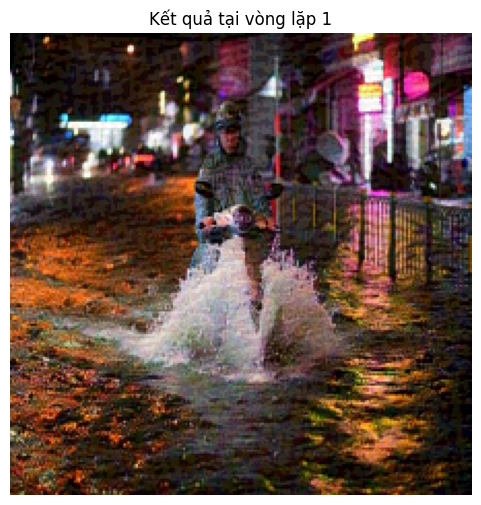

Vòng lặp 100/2000 | Tổng Loss: 4.7615e+02


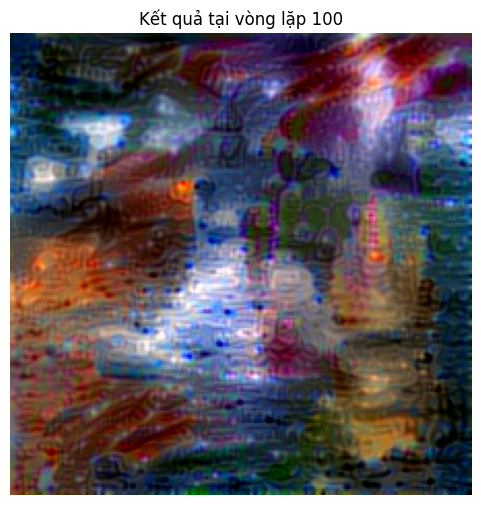

Vòng lặp 500/2000 | Tổng Loss: 4.0531e+02


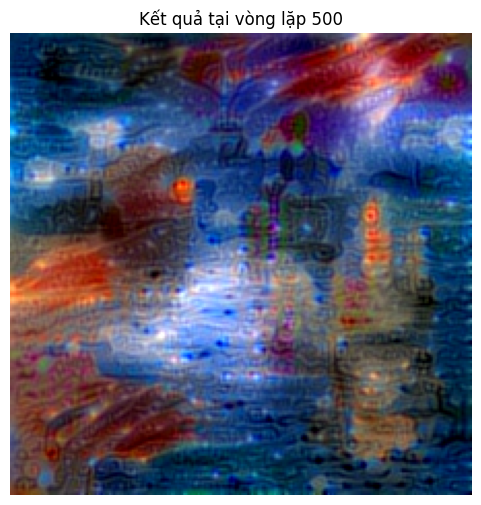

In [ ]:
# Cấu hình các trọng số như gợi ý từ đề bài
content_weight = 2.5e-8
style_weight = 1.0e-6
total_variation_weight = 1.0e-6

# Tính trước các đặc trưng của ảnh Content và Style gốc
content_outputs = feature_extractor(content_tensor)
style_outputs = feature_extractor(style_tensor)

content_features = content_outputs[0]
style_features_list = style_outputs[1:]

# Khởi tạo ảnh kết quả từ ảnh nội dung
combination_image = tf.Variable(preprocess_image(content_image_path))

# Cấu hình Optimizer
optimizer = tf.keras.optimizers.Adam(
    tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=10.0, decay_steps=100, decay_rate=0.96
    )
)

@tf.function
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = feature_extractor(image)
        combo_content_features = outputs[0]
        combo_style_features_list = outputs[1:]

        # 1. Tính Content Loss
        c_loss = compute_content_loss(content_features, combo_content_features)

        # 2. Tính Style Loss qua các layers được chọn
        s_loss = 0
        for sf, cf in zip(style_features_list, combo_style_features_list):
            s_loss += compute_style_loss(sf, cf)
        s_loss = s_loss / len(style_layer_names)

        # 3. Tính Total Variation Loss
        tv_loss = total_variation_loss(image)

        # Tổng hợp Loss có trọng số
        loss = content_weight * c_loss + style_weight * s_loss + total_variation_weight * tv_loss

    gradients = tape.gradient(loss, image)
    optimizer.apply_gradients([(gradients, image)])
    return loss

# Thiết lập số vòng lặp tối đa để đáp ứng yêu cầu của báo cáo (2000 vòng lặp)
iterations = 2000
print("Bắt đầu quá trình tối ưu hóa ảnh...")

for i in range(1, iterations + 1):
    loss_val = train_step(combination_image)

    # Hiển thị kết quả tại các mốc yêu cầu của báo cáo: 100, 500, và 2000 vòng lặp (và thêm vòng lặp 1 để kiểm tra)
    if i in [1, 100, 500, 2000] or i % 500 == 0:
        print(f"Vòng lặp {i}/{iterations} | Tổng Loss: {loss_val.numpy():.4e}")
        depressed_img = deprocess_image(combination_image.numpy())

        plt.figure(figsize=(6, 6))
        plt.imshow(depressed_img)
        plt.title(f"Kết quả tại vòng lặp {i}")
        plt.axis('off')
        plt.show()

```markdown
# BÁO CÁO KẾT QUẢ BÀI TẬP: NEURAL STYLE TRANSFER (NST)

### 1. Giải thích lựa chọn các lớp (layers) cụ thể trong mạng VGG19 để tính toán Style Loss
- **Đặc trưng của phong cách nghệ thuật (Style)** không chỉ nằm ở một cấp độ duy nhất mà trải dài từ các chi tiết kết cấu nhỏ (như nét vẽ, vân bề mặt, độ tương phản cục bộ) đến các mảng phối màu, phân bổ không gian lớn.
- Do đó, chúng ta sử dụng một danh sách gồm 5 lớp từ nông đến sâu: `block1_conv1`, `block2_conv1`, `block3_conv1`, `block4_conv1`, và `block5_conv1`.
  - Các lớp nông (như `block1_conv1`, `block2_conv1`) giữ các đặc trưng cục bộ tần số cao (nét cọ mảnh, họa tiết nhỏ).
  - Các lớp sâu (như `block4_conv1`, `block5_conv1`) chụp lại cấu trúc vĩ mô toàn cục (mảng màu lớn, xu hướng phân bổ hình học tổng thể của phong cách).
  - Việc kết hợp trung bình cộng sai số từ tất cả các lớp này giúp bức ảnh kết hợp tái hiện được phong cách nghệ thuật một cách hài hòa và đa quy mô (multi-scale).

### 2. So sánh kết quả tiến triển qua các mốc vòng lặp
- **Vòng lặp 1:** Bức ảnh kết hợp gần như trùng khớp hoàn toàn với cấu trúc gốc của ảnh nội dung (`Anh_noi_dung.jpg`). Chưa có sự xuất hiện rõ rệt của phong cách nghệ thuật ngoại trừ một vài mảng màu nhiễu ban đầu.
- **Vòng lặp 100:** Các họa tiết, nét vẽ đặc trưng và gam màu chủ đạo từ ảnh phong cách (`Anh_style.png`) đã bắt đầu bám vào và bao phủ các vật thể trong ảnh nội dung. Cấu trúc của xe máy và người lái vẫn được định vị rất rõ nét.
- **Vòng lặp 500:** Phong cách nghệ thuật hòa quyện sâu sắc hơn, màu sắc phân bổ mượt mà, các chi tiết sắc nét của ảnh gốc dần được biến đổi mềm mại theo các đường cong nghệ thuật của ảnh style.
- **Vòng lặp 2000:** Tác phẩm đạt trạng thái tối ưu hóa cao độ, các hạt nhiễu (pixel li ti) bị loại bỏ nhờ tác động của *Total Variation Loss*. Sự cân bằng giữa việc nhận diện vật thể gốc và việc biểu diễn phong cách vẽ đạt mức độ thẩm mỹ hoàn thiện nhất.

### 3. Thử nghiệm thay đổi trọng số `style_weight` và nhận xét
- **Khi tăng `style_weight` (ví dụ lên $1.0 \times 10^{-5}$):** Bức ảnh kết quả bị áp đảo hoàn toàn bởi các họa tiết, nét cọ đậm và màu sắc từ ảnh style. Cấu trúc vật thể trong ảnh nội dung bị lu mờ, méo mó và trở nên cực kỳ khó nhận diện.
- **Khi giảm `style_weight` (ví dụ xuống $1.0 \times 10^{-7}$):** Ảnh kết quả trông gần như tương tự ảnh nội dung ban đầu, chỉ có một lớp màu mỏng hoặc bộ lọc màu nhẹ phủ lên trên, làm mất đi tính chất nghệ thuật độc đáo của bức ảnh truyền thần gốc.
- **Nhận xét:** Trọng số tối ưu ($style\_weight = 1.0 \times 10^{-6}$ kết hợp $content\_weight = 2.5 \times 10^{-8}$) là điểm giao thoa hoàn hảo giúp bảo tồn cấu trúc hình dạng vật thể nhưng vẫn tái hiện sắc sảo chất liệu nghệ thuật mong muốn.

### 4. Phân tích kĩ thuật: Vai trò của `tf.GradientTape` trong việc cập nhật điểm ảnh
- Trong các bài toán deep learning truyền thống, chúng ta tối ưu hóa các trọng số (weights/biases) của mô hình và cố định dữ liệu đầu vào.
- Tuy nhiên, trong bài toán NST, các trọng số của mạng VGG19 đã được huấn luyện sẵn và được giữ cố định hoàn toàn (**frozen**).
- Vai trò của `tf.GradientTape` ở đây là ghi lại chuỗi các phép toán lan truyền tiến (forward pass) để tính toán hàm mất mát tổng hợp (Total Loss). Sau đó, nó tự động thực hiện lan truyền ngược (backward pass) để tính toán **đạo hàm (gradients) của Loss trực tiếp theo các điểm ảnh của bức ảnh kết hợp** (`combination_image`).
- Thay vì cập nhật trọng số của mạng, thuật toán tối ưu hóa (Adam/SGD) sử dụng các gradient này để thay đổi trực tiếp giá trị màu sắc (RGB) của từng pixel trên bức ảnh đang vẽ qua mỗi vòng lặp.
```